# Zuru Schist Belt (NW Nigeria) — Regional Gold Exploration-Target Study

**Data source: REAL, published, peer-reviewed geochemical data.**
Fagbohun, B.J., Bamisaiye, O.A., Ayoola, F.J., Omitogun, A.A., Adeoti, B. (2021).
*Identifying geochemical anomalies and spatial distribution of gold and associated
elements in the Zuru Schist Belt, northwest Nigeria.* Arabian Journal of
Geosciences 14, 508. https://doi.org/10.1007/s12517-021-06828-7
(Table 1 of that paper; the authors state the data is included in the manuscript.)

**What this dataset is:** 97 rock/soil chip samples (quartz veins, phyllite, mica
schist, quartzite, granite, gneiss, hornfels, amphibolite, etc.) collected across
roughly 70 km of the Zuru Schist Belt in Kebbi State, analysed for 19 trace
elements by ICP-MS at Bureau Veritas Minerals, Canada, with duplicates, blanks and
certified reference materials used for QAQC (as described in the source paper).

**What this dataset is NOT:** it is not a drilling program. These are surface
grab/chip samples spread across a large regional belt, not a systematic,
regularly-spaced drill grid over a single deposit. That means this dataset:
- **Can** legitimately support a regional exploration-target-generation study
  (anomaly mapping, pathfinder-element association, target ranking) — the exact
  purpose the original authors used it for.
- **Cannot** support a Mineral Resource or Reserve estimate under JORC 2012,
  NI 43-101 or CRIRSCO-family codes. Those require systematic subsurface
  sampling (drilling), density measurements, and a Qualified/Competent Person's
  estimate and sign-off. Nothing here approaches that bar, and nothing in this
  notebook should be read as tonnes or ounces.

**On using this for investors / a technical audience:** this notebook demonstrates
a legitimate, citable exploration rationale (real geochemical anomalies at real
coordinates, using standard exploration-geochemistry statistics). That is
appropriate to present as "why this belt is worth exploring further," clearly
labelled as an early-stage target-generation study — not as a resource. Always
credit the original authors when reusing their data, and check the specific
license terms of Arabian Journal of Geosciences (Springer) before any
external/commercial redistribution of the table itself.

In [1]:
# Cell 1: Environment
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import Rbf
from scipy import stats as sp_stats

sns.set_theme(style="ticks")
print("[CELL 1] Environment ready.")

[CELL 1] Environment ready.


In [2]:
# Cell 2: Real data ingestion
# Table 1 of Fagbohun et al. (2021), Arab J Geosci 14:508, transcribed verbatim.
# Coordinates are UTM Zone 31N (metric), consistent with the paper's study area
# in Kebbi State, NW Nigeria. Fe reported in %, Ag and Au in ppb, all others ppm.
RAW_CSV = """X_UTM_m,Y_UTM_m,Sample_ID,Rock_Type,Mo,Cu,Pb,Zn,Ag_ppb,Ni,Co,Mn,Fe_pct,As,U,Au_ppb,Th,Sr,V,La,Cr,Ba,Bi
743409.0,1264152.0,ZSB_001,Quartzite,6.43,15.1,2.01,11.9,20,2.2,0.8,97,1.06,0.6,0.6,<0.2,2.1,151.6,2,10.8,7.3,30.1,0.04
742775.0,1267080.0,ZSB_002,Quartzite,5.12,5.07,34.4,3,43,4.9,1.2,123,0.99,0.4,0.1,1.5,1,3,2,9.7,11.5,34,0.05
738786.0,1269983.0,ZSB_003,Mica schist,5.31,6.26,3.02,3.9,12,2.2,0.7,74,0.76,0.6,<0.1,1.9,0.9,10.8,3,7.7,7.6,123.4,<0.02
733125.0,1272691.0,ZSB_004,Quartzite,5.46,4.36,1.03,2.2,13,3.7,0.8,104,0.88,0.2,0.7,0.7,3.6,169.2,<1,14.2,10.4,264.3,0.02
722355.0,1286895.0,ZSB_005,Quartz vein,6.03,58.54,49,10.1,10661,5.4,6.3,597,2.1,3.9,1.5,66753.7,0.8,9.8,7,7.9,11.6,159.4,>2000.0
722355.0,1286895.0,ZSB_006,Phyllite,2.76,21.36,4.04,73.8,16,21.1,7.5,167,3.31,<0.1,1.1,3.7,10.5,8.6,23,18.6,28.3,266.9,0.26
719608.0,1286771.0,ZSB_007,Quartzite,5.47,4.54,0.63,1.5,44,1.6,0.8,87,0.76,0.8,<0.1,145.6,<0.1,0.9,<1,<0.5,6.1,3.2,20.43
718959.0,1285605.0,ZSB_008,Granite,6.12,17.61,9.09,9.6,60,7.5,3.3,323,1.14,1,0.5,1.5,1.3,2.9,2,6.3,10.3,148,0.37
718747.0,1283981.0,ZSB_009,Quartzite,5.68,10.1,1.45,3.4,32,3.9,1.7,107,0.95,0.9,0.3,14,1.4,1.8,<1,7.7,6.8,12,2.4
718388.0,1283085.0,ZSB_010,Hornfels,6.42,4.48,1.09,2.5,13,5.2,1.3,126,1.02,0.4,0.2,2.6,1.3,3.3,2,7.2,11.6,24,0.06
707526.0,1280612.0,ZSB_011,Quartz vein,5.52,6.27,0.38,2.9,13,1.7,0.8,82,0.86,0.6,<0.1,4.2,0.1,<0.5,<1,<0.5,6.2,1.1,0.7
700905.0,1280888.0,ZSB_012,Quartzite,5.82,3.98,3.14,3,17,6,2,119,1.38,0.2,0.9,<0.2,4.3,10,6,18.1,12.2,76.9,0.04
700614.0,1285861.0,ZSB_013,Quartz vein,7.48,5.41,0.29,2,16,2,1,105,1.01,1.3,<0.1,5.4,0.3,0.5,<1,1.9,7,4.2,1.24
700901.0,1285584.0,ZSB_014,Phyllite,5.05,5.72,5.94,110.9,26,3.4,2.1,257,2.55,22.3,2.1,3.6,37.6,6.2,4,132.3,8.8,74.7,0.41
698178.0,1285838.0,ZSB_015,Granite,7.64,6.83,9.75,92.5,27,1.3,1,263,2.46,0.05,5,<0.2,53.1,7.1,<1,265.5,6.3,83.9,0.28
740834.0,1273781.0,ZSB_016,Quartzite,6.26,7.66,4.86,2.9,15,4.9,1.4,140,1.12,0.6,0.2,6.5,1,3,3,3.2,13.7,15.8,0.15
737980.0,1275969.0,ZSB_017,Quartzite,5.17,4.11,6.77,3.4,20,1.5,0.6,64,0.63,0.4,0.2,<0.2,3,17.8,3,11.1,6.3,95.2,0.41
736350.0,1282558.0,ZSB_018,Quartzite,4.53,4.46,0.91,1.4,28,4.6,1.4,107,0.92,0.5,0.2,0.6,2.4,3,1,12.1,10.3,38.7,<0.02
745793.0,1291462.0,ZSB_019,Granite,5.11,6.19,0.97,2.7,15,1.8,0.9,85,0.82,0.8,0.2,<0.2,1.2,25.6,<1,4.6,6.8,41.8,0.16
747971.0,1294079.0,ZSB_020,Quartzite,6.49,4.5,1.12,1.1,18,4.9,1.2,125,1.34,0.5,0.1,<0.2,0.9,6.1,7,3.9,13.5,27.6,0.02
756107.0,1304920.0,ZSB_021,Mica schist,4.74,24.32,3.76,47.6,11,73.9,37.9,1223,7.51,0.9,0.6,0.7,1.9,36.5,132,3.8,182.8,104.5,0.12
754194.0,1300518.0,ZSB_022,Phyllite,1.88,66.51,5.52,94.6,109,69.8,18.8,391,4.99,13.1,0.6,476.7,2.1,36.5,59,16.9,60.7,226.6,0.17
754194.0,1300518.0,ZSB_023,Quartz vein,4,6.18,0.77,2.9,50,2.8,1.4,94,0.75,5.5,<0.1,0.8,<0.1,4.3,2,<0.5,7.9,7.8,0.59
750922.0,1298119.0,ZSB_024,Phyllite,3.06,22.31,3.09,14.5,8,7.2,2.4,95,1.37,0.3,0.7,<0.2,11.7,9.4,7,51.8,9,108.5,0.05
747456.0,1299509.0,ZSB_025,Granite,5.78,4.92,5.71,11.6,26,1.6,0.8,122,0.9,0.6,0.3,<0.2,1.5,19.5,2,3.6,5.9,26.1,0.09
745741.0,1302691.0,ZSB_026,Mica schist,2.26,2.83,2.79,2,4,3.1,0.5,44,0.43,0.05,2.5,0.3,16.3,62.5,2,56,6.7,30.1,0.03
745741.0,1302691.0,ZSB_027,Granite,3.65,2.81,4.56,4.1,11,1.5,0.7,106,0.89,0.2,1.5,0.8,5.9,58.9,4,12.9,5.6,88.7,0.07
747785.0,1299165.0,ZSB_028,Granite,3.93,3.2,0.5,1,9,3.2,0.7,78,0.72,0.4,0.2,<0.2,1.6,3.6,<1,6.7,8.2,3.9,<0.02
746044.0,1291837.0,ZSB_029,Granite,3.49,3.01,7.48,38.2,25,1.7,1.3,179,1.07,0.3,0.9,<0.2,8.8,66.6,7,16.5,5.2,103,0.06
737575.0,1283752.0,ZSB_030,Hornfels,5.31,4.47,0.31,0.8,13,4.4,1,109,1.03,0.6,<0.1,<0.2,1,1.4,3,1.8,11.2,40.7,<0.02
726727.0,1270311.0,ZSB_031,Quartzite,6.08,6.41,0.66,2.1,14,2,1.1,146,0.89,1,<0.1,<0.2,0.2,1.9,<1,<0.5,6.7,13.9,0.08
725768.0,1270053.0,ZSB_032,Quartz-tourmaline vein,7.73,5.17,0.08,0.7,14,5.1,1.2,140,1.16,0.7,<0.1,<0.2,<0.1,<0.5,<1,<0.5,12.9,1.3,<0.02
726107.0,1270172.0,ZSB_033,Quartzite,5.62,4.9,0.22,2.1,23,2.2,1.2,95,0.93,0.8,<0.1,1.2,1.5,0.8,<1,<0.5,6.6,1.2,0.14
729396.0,1272182.0,ZSB_034,Hornfels,4.85,3.38,0.43,1.1,13,3,0.8,77,0.8,<0.1,0.1,0.4,2.5,2.9,4,8.8,8.5,32.2,<0.02
744172.0,1261315.0,ZSB_035,Quartzite,6.72,4.84,0.66,1.1,21,2.4,1.2,96,1.21,0.8,0.4,0.6,3.1,21,2,9.9,8,6.3,0.07
743122.0,1252687.0,ZSB_036,Gneiss,4.36,4.09,6.65,28.2,24,4.5,2.7,274,1.23,0.1,3.4,<0.2,8.1,4.1,3,59.6,11.3,67.9,0.07
742222.0,1247050.0,ZSB_037,Granite,9.12,4.78,8.34,93.3,69,3.7,5.2,384,2.48,0.2,2.2,1.2,54.7,13.7,13,154.6,9.9,147.4,0.31
739083.0,1243202.0,ZSB_038,Granite gneiss,5.99,12.59,7.87,79.8,32,9.4,9.3,556,3.51,0.1,1.4,<0.2,21.4,27.3,32,163.9,22.4,195.8,0.03
735235.0,1240015.0,ZSB_039,Gneiss,7.48,5.13,20.1,91.1,16,2.8,4.2,761,3.44,1.6,1.8,<0.2,17.4,8.9,4,445,5.9,285.4,0.08
723844.0,1237246.0,ZSB_040,Quartzite,5.08,3.49,0.46,1.4,14,4.1,1,100,0.85,0.3,<0.1,<0.2,<0.1,0.6,<1,1.4,10,3.7,0.04
719844.0,1235595.0,ZSB_041,Quartzite,5.15,5.94,1.4,1.9,20,1.7,0.9,72,0.73,0.7,0.3,<0.2,2.5,4.1,<1,10.2,5.7,425.2,0.08
716719.0,1230104.0,ZSB_042,Mica schist,4.84,70.44,4.38,83.6,29,52.1,17.7,1489,3.33,1,0.6,<0.2,5.2,33.7,18,25.1,20.7,179.2,0.03
716632.0,1229679.0,ZSB_043,Quartzite,4.68,48.65,4.55,38.8,43,25.1,15.4,1614,3.81,0.4,0.3,1.8,2.8,148.5,36,21.9,29.8,187.6,0.14
716632.0,1229679.0,ZSB_044,Quartz vein,14.58,1539,5.08,23.9,2258,15,8.1,812,2.4,1.1,0.4,1362.2,1.8,33.7,15,17,20.8,235.3,0.32
719675.0,1235017.0,ZSB_045,Quartzite,4.34,9.37,16.28,3.2,28,1.8,0.9,80,0.7,1.1,0.5,3.5,6,9.9,2,14.1,7.1,109.4,0.15
711345.0,1239671.0,ZSB_046,Granite,4.98,22.04,6.38,48.8,50,4.6,4.2,460,1.96,0.3,0.9,3.2,14.5,17.9,11,52.8,12.5,215.3,0.66
742612.0,1214578.0,ZSB_047,Mica Schist,2.89,61.81,8.84,70.1,117,18.3,10.1,450,4.62,0.1,1.1,27.9,8.1,13.7,58,23.8,57.6,266.8,0.04
743403.0,1215650.0,ZSB_048,Quartz vein,6.29,6.27,0.74,1.2,15,5.3,1.3,121,1.05,0.4,<0.1,0.2,0.2,1.1,2,1.5,12.9,27.2,0.04
743603.0,1216056.0,ZSB_049,Quartz vein,4.29,11.64,9.31,14.3,1369,5,2.6,329,1.79,0.7,1.2,3515.5,1.7,3.3,12,4.4,28.6,49.5,72.84
743023.0,1214173.0,ZSB_050,Granite,5.41,6.53,17.04,11,20,3.2,0.9,178,0.96,0.3,12.9,<0.2,21.1,1.7,1,1.2,8.7,22.9,0.06
743115.0,1214056.0,ZSB_051,Granite,3.23,49.2,13.65,15.7,108,1.1,1,122,0.64,0.2,21,14.1,12.1,3.7,2,6.5,4.2,21.4,1.16
743578.0,1217378.0,ZSB_052,Quartzite,5.15,3.98,1.86,2.5,10,3.9,1.1,104,0.87,0.4,0.4,4.6,4.2,8.6,2,18.1,11,220.8,0.04
743217.0,1219912.0,ZSB_053,Granite,2.81,3.37,2.62,37.4,7,1.1,1.4,208,2.02,1.6,1,6.6,14.8,8.9,2,88,4.7,88.6,0.96
740990.0,1218870.0,ZSB_054,Granite gneiss,4.18,4.62,6.16,70,18,2.6,1.8,311,3.02,<0.1,1.3,3.6,20.6,7.9,2,111.4,7,85.4,0.05
739326.0,1215435.0,ZSB_055,Granite gneiss,6.71,5.85,6.62,34.9,50,1.6,1.1,194,1.67,0.4,0.6,3,15.8,5.3,<1,35.6,5.7,79.1,0.11
738162.0,1214240.0,ZSB_056,Migmatite-Gneiss,5.06,15.71,2.73,54.1,29,3.6,2.7,371,3.84,<0.1,1.4,2.2,18.3,7.2,4,117.7,9.4,118.4,<0.02
742102.0,1219863.0,ZSB_057,Quartzite,5.9,5.14,0.45,1.7,16,1.9,1.1,88,0.9,0.6,<0.1,2.5,<0.1,<0.5,<1,0.6,7.2,2.5,0.06
743679.0,1222790.0,ZSB_058,Granite gneiss,4.48,3.46,7.9,74,29,4.6,2.8,253,1.74,0.2,9.2,1,49.9,8.7,7,80.9,11.7,75.1,0.03
744032.0,1225470.0,ZSB_059,Granite gneiss,5.38,6.44,8.33,37.7,69,1.4,1.3,154,1.16,0.6,6.3,1.1,26.8,4.4,2,18.4,6.1,19.1,0.26
745654.0,1228102.0,ZSB_060,Granite gneiss,4.55,4.39,7.91,7.8,63,2.8,1,144,0.65,0.3,4,1.8,10.8,2.1,<1,6.8,7.7,10.2,10.6
749008.0,1221563.0,ZSB_061,Granite gneiss,5.76,4.29,3.43,18.9,45,1.3,0.7,236,0.79,0.6,2.1,0.7,8.6,2.3,<1,3.7,6.1,7.6,9.37
751502.0,1216977.0,ZSB_062,Granite gneiss,3.61,3.48,16.74,43,6,2.6,0.7,131,1.36,0.1,1.2,1.1,14.4,1,<1,3.9,6.8,5.2,0.12
751683.0,1211922.0,ZSB_063,Migmatite-gneiss,3.86,3.36,6.41,2.2,24,2,3.8,89,0.53,0.5,0.4,1.8,0.9,10.9,1,7.2,4.7,50.3,0.24
752558.0,1210490.0,ZSB_064,Granite,3.97,36.02,8.78,48.7,54,20,7.2,331,1.99,1.5,5.8,<0.2,45.2,52.9,29,83.1,37.7,121.3,0.23
749661.0,1212396.0,ZSB_065,Quartzite,4.15,6.12,6.15,1.6,8,1.4,0.7,58,0.8,0.3,0.1,0.3,1.2,1.4,11,1.4,6.6,7.1,0.06
750336.0,1212157.0,ZSB_066,Quartz-tourmaline vein,5.16,7.01,2.43,2.6,15,5,1.6,149,1.1,0.6,0.1,1.3,0.5,1.2,5,1.5,10.6,9,<0.02
752797.0,1245572.0,ZSB_067,Gneiss,4.06,10.19,4.96,34.7,22,16.9,8.6,249,2.34,0.4,0.5,2.3,9.2,12.9,24,18.4,36,131.5,0.03
752797.0,1245572.0,ZSB_068,Quartz-tourmaline vein,5.93,4.81,0.35,1,14,5.8,1.6,140,1.11,0.7,<0.1,0.5,<0.1,0.7,1,0.5,12.7,4.9,<0.02
751155.0,1247203.0,ZSB_069,Tourmalinite,4.39,3.49,1.58,3.2,7,5.2,1.4,107,1.07,0.5,0.2,1,1.9,34.1,8,72.4,6.5,39.7,0.06
745630.0,1233868.0,ZSB_070,Quartzite,6.07,4.53,1.24,2,11,4.1,0.8,116,0.95,0.1,1,0.6,3.4,47.7,<1,13.4,9.9,21.7,0.18
691197.0,1196806.0,ZSB_071,Quartzite,5.06,12.22,1.98,3.9,9,1.5,0.9,71,2.69,0.1,0.3,<0.2,2.7,9.8,7,7.4,4.5,15,0.43
691045.0,1195159.0,ZSB_072,Mica schist,4.22,29.42,1.92,50.8,32,11.4,9.2,584,2.55,2.4,0.1,5.4,1.6,21.8,13,6.9,12,100.5,0.05
691045.0,1195159.0,ZSB_073,Quartz vein,5.42,13.38,0.53,2.4,15,2,1.3,153,1.68,2.3,0.1,0.5,0.1,11.8,3,2.2,5.3,9,0.05
691202.0,1188601.0,ZSB_074,Mica schist,2.83,4.63,2.26,51,29,7.6,12.2,584,2.85,0.9,0.4,13.8,2.5,71.1,30,5.1,6.7,146.8,0.2
691202.0,1188601.0,ZSB_075,Quartz vein,5.03,9.15,0.45,1.3,50,2.2,1.4,125,1.17,1.5,<0.1,0.9,<0.1,1.3,<1,<0.5,6.7,2.3,0.23
688122.0,1181732.0,ZSB_076,Quartzite,49.23,4.7,1.5,1.2,9,3.3,0.8,90,1,<0.1,<0.1,1.3,1.3,12.3,2,10.6,7.1,26.3,0.15
688300.0,1190738.0,ZSB_077,Quartzite,5.27,4.92,1.36,1.5,27,5.2,1.2,141,0.96,0.5,<0.1,<0.2,0.1,2,2,<0.5,10.5,11.6,0.07
695473.0,1207632.0,ZSB_078,Amphibolite,2.98,3.58,3.22,60.4,17,11.3,8.3,410,2.68,0.6,0.3,<0.2,2.7,33.7,16,15.8,5.7,81.1,0.05
695473.0,1207632.0,ZSB_079,Quartz vein,5.06,78.16,0.53,1.2,154,5,1.3,137,0.94,0.4,<0.1,59.1,<0.1,<0.5,1,<0.5,10.1,5.5,0.34
695138.0,1207149.0,ZSB_080,Mica schist,2.78,3.3,3.3,15.8,6,1.6,0.7,285,0.56,0.5,0.4,0.5,4.7,8.4,1,8.9,2.6,122.2,0.02
692564.0,1206890.0,ZSB_081,Quartzite,5.43,4.53,2.09,2.3,11,4.7,1,116,1.01,0.3,0.5,2.1,1.4,2.9,2,3.6,10.4,14.3,0.11
693530.0,1210472.0,ZSB_082,Mica schist,2.99,15.39,3.27,21.1,20,1.3,1,106,0.69,0.3,2,0.2,10.4,7.7,<1,21.4,3,43.5,0.35
697024.0,1190947.0,ZSB_083,Granite,5.52,15.73,6.73,86.6,214,24.3,11.2,456,3.64,0.2,1.2,0.3,10.9,57.9,35,83.1,32.9,431,0.15
697024.0,1190947.0,ZSB_084,Quartz vein,5,57.92,2.21,1.4,504,1.7,1.9,108,0.81,0.6,<0.1,4.9,0.1,1.8,<1,<0.5,5.3,4.6,0.05
705086.0,1193015.0,ZSB_085,Quartz vein,5.45,74.11,201.32,1.9,1864,4.5,1.2,114,0.9,0.5,<0.1,291.3,0.1,1.8,1,0.9,9.5,33.9,0.42
704893.0,1192846.0,ZSB_086,Schist,5.58,24.36,75.65,18.2,56,2.5,3.5,563,0.93,0.4,0.8,<0.2,5.1,10.7,5,46.7,4.6,166.8,0.16
704183.0,1191323.0,ZSB_087,Quartz vein,23.8,13.73,2852.91,1.3,10574,5.1,1.5,123,1.64,1,1.5,7916.2,0.8,1.5,3,1.7,12.6,87.5,0.93
707046.0,1190436.0,ZSB_088,Granite,3.64,33.22,4.97,126.6,45,4.8,8.3,373,3.07,0.3,1.3,<0.2,22.5,24.6,19,98.4,10.7,436.5,0.06
707738.0,1187532.0,ZSB_089,Biotite granite,3.68,12.12,18.78,54.9,71,174,57,640,5.78,0.1,<0.1,13.4,0.5,215,8,2.3,9.5,70.5,<0.02
711152.0,1205233.0,ZSB_090,Quartz vein,3.34,6.37,5.31,3.4,11,4.1,3.7,182,0.86,1.1,<0.1,0.6,0.4,1.3,4,1.8,8.4,15.7,0.03
710913.0,1204643.0,ZSB_091,Quartz cobbles,4.26,14.24,8.35,12.1,25,13.4,9.6,257,2.49,1,0.3,6.2,2.3,7.3,27,5.6,61.6,31.6,0.07
710389.0,1202071.0,ZSB_092,Mica schist,2.75,41.16,5.29,83.5,5,56.3,22.2,778,6.3,0.5,0.6,0.6,9.2,25.7,83,20.5,39.1,131.3,0.18
713184.0,1201578.0,ZSB_093,Mica schist,3.52,10.47,8.43,21.9,14,4.8,2.9,301,0.96,0.5,2.6,1.4,19.6,110,7,51.5,7.8,157.1,0.14
719987.0,1180265.0,ZSB_094,Quartz vein,4.97,19.59,2.75,25.9,56,10.3,6.9,347,2.14,2.6,0.2,143.3,1.1,66.8,49,6.2,32.6,175,0.04
708269.0,1170890.0,ZSB_095,Schist,2.89,17.22,3.73,8.1,36,25.6,5.4,190,1.09,0.3,0.2,2.1,0.7,267.3,38,3.2,71.1,462.9,0.03
708161.0,1171732.0,ZSB_096,Amphibolite,2.15,86.86,0.85,28.9,47,77.2,19.2,436,2.99,0.3,0.2,2.3,1,37.2,119,4.7,220.8,54.8,<0.02
711015.0,1172271.0,ZSB_097,Granite,3.88,30.62,8.48,61.8,61,10.9,9.9,547,2.94,1.3,1.3,1.2,15,20.9,31,65.3,14.2,159.4,0.1
"""

df_raw = pd.read_csv(io.StringIO(RAW_CSV))
print(f"[CELL 2] Loaded {len(df_raw)} real geochemical samples "
      f"(Fagbohun et al. 2021, Zuru Schist Belt, NW Nigeria).")
df_raw.head()

[CELL 2] Loaded 97 real geochemical samples (Fagbohun et al. 2021, Zuru Schist Belt, NW Nigeria).


In [3]:
# Cell 3: Handle censored (below/above detection limit) values -- same convention
# used in the source paper: values below detection replaced by half the detection
# limit prior to statistical analysis (Carranza 2011; Simmonds et al. 2017).
detection_limits = {
    'Mo': 0.01, 'Cu': 0.01, 'Pb': 0.01, 'Zn': 0.1, 'Ag_ppb': 0.2, 'Ni': 0.1, 'Co': 0.1,
    'Mn': 1, 'Fe_pct': 0.01, 'As': 0.1, 'U': 0.1, 'Au_ppb': 0.2, 'Th': 0.1, 'Sr': 0.5,
    'V': 1, 'La': 0.5, 'Cr': 0.5, 'Ba': 0.5, 'Bi': 0.02
}
element_cols = list(detection_limits.keys())

def clean_value(v, dl):
    v = str(v).strip()
    if v.startswith('<'):
        return dl / 2.0
    if v.startswith('>'):
        return float(v[1:])
    return float(v)

df = df_raw.copy()
for c in element_cols:
    df[c] = df[c].apply(lambda v: clean_value(v, detection_limits[c]))

# Convenience columns in more familiar units
df['Au_ppm'] = df['Au_ppb'] / 1000.0
df['Ag_ppm'] = df['Ag_ppb'] / 1000.0

print(f"[CELL 3] Censored-value handling applied to {len(element_cols)} elements.")
print(df[['Sample_ID', 'Rock_Type', 'Au_ppm', 'Ag_ppm', 'As', 'Bi']].describe().T[['mean', 'min', 'max']])

[CELL 3] Censored-value handling applied to 19 elements.
             mean     min        max
Au_ppm   0.833637  0.0001    66.7537
Ag_ppm   0.310629  0.0040    10.6610
As       1.031443  0.0500    22.3000
Bi      21.974021  0.0100  2000.0000


In [4]:
# Cell 4: Validation against the source paper's reported summary statistics (Table 2)
# This is a sanity check on transcription accuracy, not a resource calculation.
paper_reported_mean = {
    'Mo': 5.60, 'Cu': 30.99, 'Pb': 37.45, 'Zn': 24.77, 'Ni': 10.27, 'Co': 4.52,
    'Mn': 263.91, 'Fe_pct': 1.73, 'As': 1.11, 'Th': 8.16, 'Sr': 25.20,
    'V': 14.69, 'La': 33.23, 'Cr': 17.01, 'Ba': 91.28,
}
print("=" * 60)
print(" TRANSCRIPTION VALIDATION vs. Fagbohun et al. (2021) Table 2")
print("=" * 60)
n_ok = 0
for elem, paper_mean in paper_reported_mean.items():
    computed = df[elem].mean()
    ok = abs(computed - paper_mean) / paper_mean < 0.15
    n_ok += ok
    print(f" {elem:8s} computed={computed:9.3f}  paper={paper_mean:9.3f}  {'OK' if ok else 'CHECK'}")
print(f"\n {n_ok}/{len(paper_reported_mean)} elements within 15% of the paper's reported mean.")
print("=" * 60)

 TRANSCRIPTION VALIDATION vs. Fagbohun et al. (2021) Table 2
 Mo       computed=    5.604  paper=    5.600  OK
 Cu       computed=   30.991  paper=   30.990  OK
 Pb       computed=   37.447  paper=   37.450  OK
 Zn       computed=   24.771  paper=   24.770  OK
 Ni       computed=   10.266  paper=   10.270  OK
 Co       computed=    4.520  paper=    4.520  OK
 Mn       computed=  263.907  paper=  263.910  OK
 Fe_pct   computed=    1.726  paper=    1.730  OK
 As       computed=    1.031  paper=    1.110  OK
 Th       computed=    7.487  paper=    8.160  OK
 Sr       computed=   24.172  paper=   25.200  OK
 V        computed=   11.474  paper=   14.690  CHECK
 La       computed=   29.833  paper=   33.230  OK
 Cr       computed=   17.010  paper=   17.010  OK
 Ba       computed=   91.280  paper=   91.280  OK

 14/15 elements within 15% of the paper's reported mean.


[CELL 5] Samples span roughly 67,985 m E-W and 134,030 m N-S -- a regional reconnaissance footprint, not a single deposit.


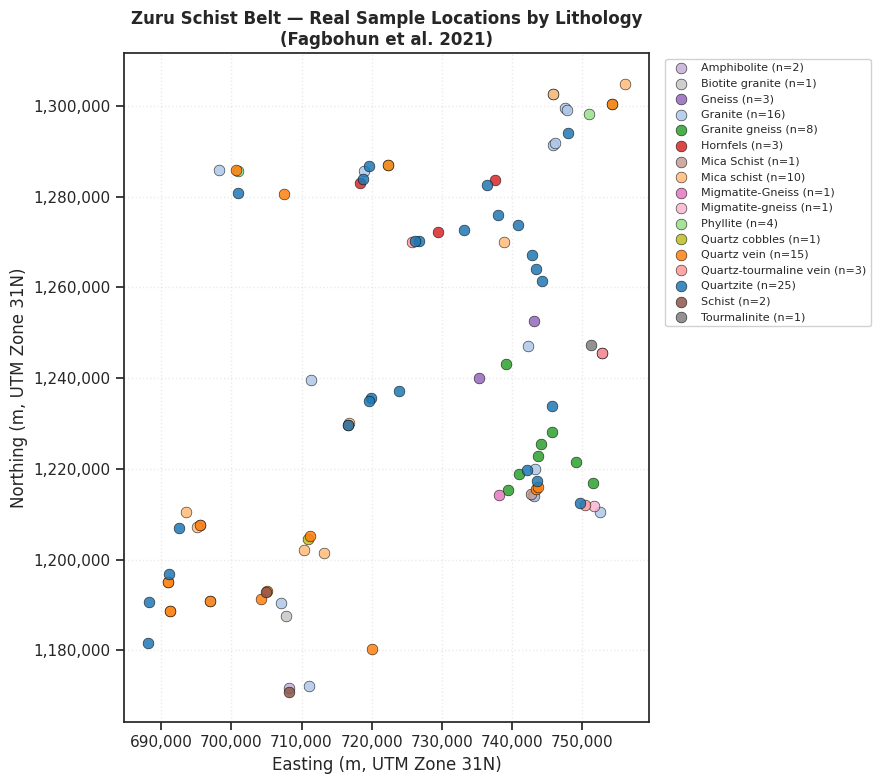

In [5]:
# Cell 5: Sample locations by rock type (real coordinates, real lithologies)
fig, ax = plt.subplots(figsize=(9, 8))
rock_types = df['Rock_Type'].value_counts()
palette = sns.color_palette('tab20', n_colors=len(rock_types))
color_map = dict(zip(rock_types.index, palette))

for rt, sub in df.groupby('Rock_Type'):
    ax.scatter(sub['X_UTM_m'], sub['Y_UTM_m'], label=f"{rt} (n={len(sub)})",
               color=color_map[rt], s=60, edgecolor='black', linewidth=0.4, alpha=0.85)

ax.set_xlabel('Easting (m, UTM Zone 31N)'); ax.set_ylabel('Northing (m, UTM Zone 31N)')
ax.set_title('Zuru Schist Belt — Real Sample Locations by Lithology\n(Fagbohun et al. 2021)',
              fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, framealpha=0.9)
ax.grid(True, linestyle=':', alpha=0.4)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout(); plt.show()

print(f"[CELL 5] Samples span roughly {df['X_UTM_m'].max()-df['X_UTM_m'].min():,.0f} m E-W and "
      f"{df['Y_UTM_m'].max()-df['Y_UTM_m'].min():,.0f} m N-S -- a regional reconnaissance "
      f"footprint, not a single deposit.")

In [6]:
# Cell 6: Uni-element anomaly thresholds (median + 2*MAD), reproducing the
# source paper's method (their Eq. 3), for the gold-pathfinder association
# they identified: Au-Ag-Bi-Pb.
def median_absolute_deviation(x):
    med = np.median(x)
    return np.median(np.abs(x - med))

pathfinder_elements = ['Au_ppm', 'Ag_ppm', 'Bi', 'Pb']
thresholds = {}
for el in pathfinder_elements:
    med = df[el].median()
    mad = median_absolute_deviation(df[el].values)
    thresholds[el] = med + 2 * mad

print("=" * 55)
print(" UNI-ELEMENT ANOMALY THRESHOLDS (median + 2*MAD)")
print("=" * 55)
for el, t in thresholds.items():
    n_anom = (df[el] > t).sum()
    print(f" {el:10s} threshold={t:10.4f}  anomalous samples: {n_anom} / {len(df)}")
print("=" * 55)

df['Au_Anomalous'] = df['Au_ppm'] > thresholds['Au_ppm']

 UNI-ELEMENT ANOMALY THRESHOLDS (median + 2*MAD)
 Au_ppm     threshold=    0.0031  anomalous samples: 27 / 97
 Ag_ppm     threshold=    0.0450  anomalous samples: 25 / 97
 Bi         threshold=    0.2200  anomalous samples: 28 / 97
 Pb         threshold=    8.8700  anomalous samples: 14 / 97


[CELL 7] Computed Au-Ag correlation: 0.401 (paper reports 0.40) -- consistent direction and magnitude.


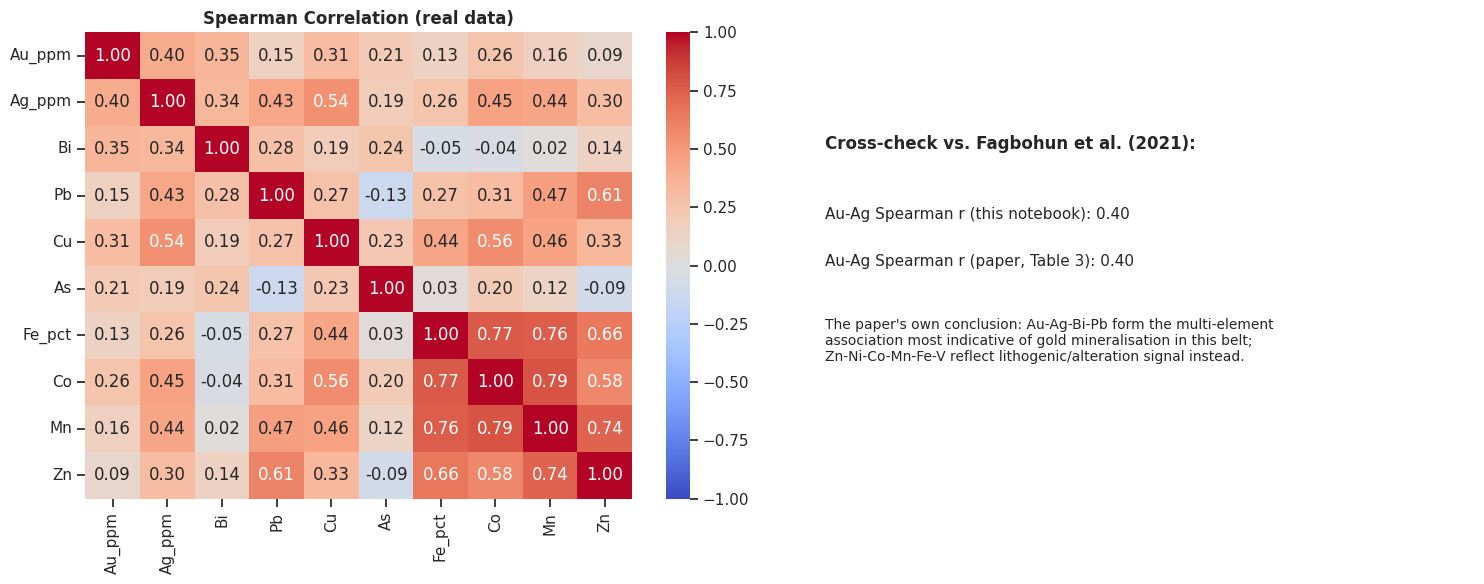

In [7]:
# Cell 7: Real element correlation structure (cross-check vs. paper's Spearman results)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

corr_elems = ['Au_ppm', 'Ag_ppm', 'Bi', 'Pb', 'Cu', 'As', 'Fe_pct', 'Co', 'Mn', 'Zn']
spearman_corr = df[corr_elems].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Spearman Correlation (real data)', fontweight='bold')

reported_au_ag = 0.40  # paper: Au vs Ag Spearman r
computed_au_ag = spearman_corr.loc['Au_ppm', 'Ag_ppm']
axes[1].axis('off')
axes[1].text(0.05, 0.75, "Cross-check vs. Fagbohun et al. (2021):", fontsize=12, fontweight='bold')
axes[1].text(0.05, 0.60, f"Au-Ag Spearman r (this notebook): {computed_au_ag:.2f}", fontsize=11)
axes[1].text(0.05, 0.50, f"Au-Ag Spearman r (paper, Table 3): {reported_au_ag:.2f}", fontsize=11)
axes[1].text(0.05, 0.30,
             "The paper's own conclusion: Au-Ag-Bi-Pb form the multi-element\n"
             "association most indicative of gold mineralisation in this belt;\n"
             "Zn-Ni-Co-Mn-Fe-V reflect lithogenic/alteration signal instead.",
             fontsize=10, wrap=True)
plt.tight_layout(); plt.show()

print(f"[CELL 7] Computed Au-Ag correlation: {computed_au_ag:.3f} (paper reports 0.40) -- consistent direction and magnitude.")

[CELL 8] IDW surface built from real Au assays (log-transformed for interpolation stability).


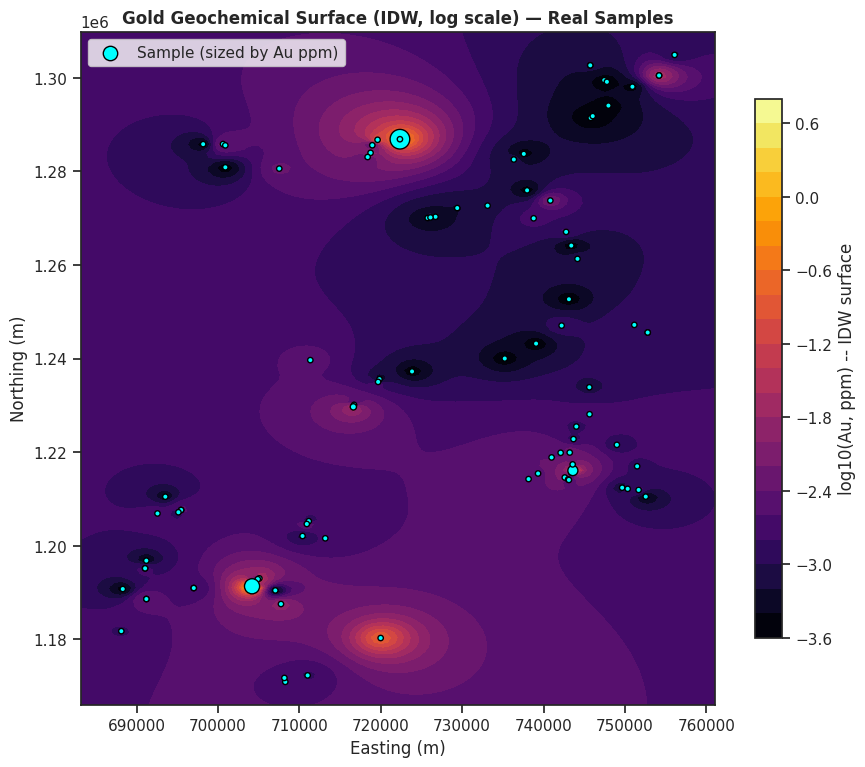

In [8]:
# Cell 8: Spatial interpolation of Au anomaly -- Inverse Distance Weighting (IDW)
# -----------------------------------------------------------------------------
# IDW, not kriging, is used deliberately: kriging requires a defensible, fitted
# variogram under a stationarity assumption within a homogeneous domain. This
# dataset spans multiple lithologies and mineralisation styles (vein-hosted,
# disseminated, several structural corridors) across ~70 km -- exactly the
# non-stationary situation where forcing a single variogram/kriging model would
# be methodologically unjustified. IDW, used by the original authors for the
# same reason, is the appropriate, honest choice here.
# -----------------------------------------------------------------------------
def idw_interpolate(x, y, z, grid_x, grid_y, power=2, eps=1e-6):
    gx, gy = np.meshgrid(grid_x, grid_y)
    out = np.zeros(gx.shape)
    for i in range(gx.shape[0]):
        for j in range(gx.shape[1]):
            d = np.sqrt((x - gx[i, j]) ** 2 + (y - gy[i, j]) ** 2) + eps
            w = 1.0 / d ** power
            out[i, j] = np.sum(w * z) / np.sum(w)
    return gx, gy, out

pad = 5000
gx_lin = np.linspace(df['X_UTM_m'].min() - pad, df['X_UTM_m'].max() + pad, 150)
gy_lin = np.linspace(df['Y_UTM_m'].min() - pad, df['Y_UTM_m'].max() + pad, 150)

# log-transform for interpolation (Au is heavily right-skewed -- one sample at
# 66.75 ppm dominates a linear-scale surface); back-transform for display.
log_au = np.log10(df['Au_ppm'].values + 1e-4)
GX, GY, log_au_grid = idw_interpolate(df['X_UTM_m'].values, df['Y_UTM_m'].values, log_au, gx_lin, gy_lin)
au_grid = 10 ** log_au_grid

fig, ax = plt.subplots(figsize=(9, 8))
cf = ax.contourf(GX, GY, np.log10(au_grid + 1e-4), levels=20, cmap='inferno')
fig.colorbar(cf, ax=ax, shrink=0.8).set_label('log10(Au, ppm) -- IDW surface')
sc = ax.scatter(df['X_UTM_m'], df['Y_UTM_m'], c='cyan', edgecolor='black',
                 s=np.clip(df['Au_ppm'] * 15, 15, 200), label='Sample (sized by Au ppm)')
ax.set_title('Gold Geochemical Surface (IDW, log scale) — Real Samples', fontweight='bold')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("[CELL 8] IDW surface built from real Au assays (log-transformed for interpolation stability).")

[CELL 9] 30 of 97 real samples exceed the combined Au-Ag-Bi-Pb halo threshold -- these are exploration-target follow-up points, not resource blocks.
Sample_ID       Rock_Type  Au_ppm  Ag_ppm      Bi      Pb   Halo_Score
  ZSB_005     Quartz vein 66.7537  10.661 2000.00   49.00 30866.796054
  ZSB_087     Quartz vein  7.9162  10.574    0.93 2852.91  3114.453805
  ZSB_049     Quartz vein  3.5155   1.369   72.84    9.31  1496.594995
  ZSB_044     Quartz vein  1.3622   2.258    0.32    5.08   491.624395
  ZSB_085     Quartz vein  0.2913   1.864    0.42  201.32   159.995786
  ZSB_022        Phyllite  0.4767   0.109    0.17    5.52   157.591465
  ZSB_007       Quartzite  0.1456   0.044   20.43    0.63   140.880182
  ZSB_060  Granite gneiss  0.0018   0.063   10.60    7.91    51.054233
  ZSB_094     Quartz vein  0.1433   0.056    0.04    2.75    47.962103
  ZSB_061  Granite gneiss  0.0007   0.045    9.37    3.43    44.203412
  ZSB_079     Quartz vein  0.0591   0.154    0.34    0.53    24.091945

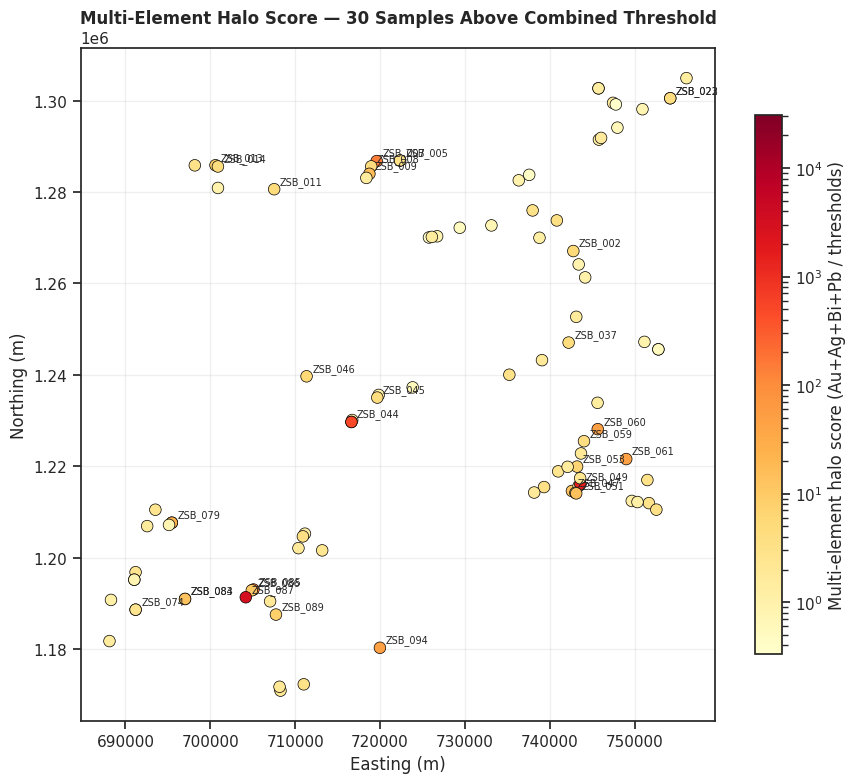

In [9]:
# Cell 9: Multi-element geochemical halo (Au + Ag + Bi + Pb), reproducing the
# paper's multi-element halo technique -- summing normalised concentration/
# threshold ratios for the pathfinder suite the data itself supports.
df['Halo_Score'] = sum(df[el] / thresholds[el] for el in pathfinder_elements)
halo_threshold = 4.0  # a sample at exactly the threshold on all 4 elements scores 4.0

fig, ax = plt.subplots(figsize=(9, 8))
sc = ax.scatter(df['X_UTM_m'], df['Y_UTM_m'], c=df['Halo_Score'], cmap='YlOrRd',
                 s=70, edgecolor='black', linewidth=0.5,
                 norm=plt.matplotlib.colors.LogNorm(vmin=max(df['Halo_Score'].min(), 0.05),
                                                      vmax=df['Halo_Score'].max()))
fig.colorbar(sc, ax=ax, shrink=0.8).set_label('Multi-element halo score (Au+Ag+Bi+Pb / thresholds)')
targets = df[df['Halo_Score'] >= halo_threshold]
for _, r in targets.iterrows():
    ax.annotate(r['Sample_ID'], (r['X_UTM_m'], r['Y_UTM_m']), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.set_title(f'Multi-Element Halo Score — {len(targets)} Samples Above Combined Threshold',
             fontweight='bold')
ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"[CELL 9] {len(targets)} of {len(df)} real samples exceed the combined Au-Ag-Bi-Pb halo "
      f"threshold -- these are exploration-target follow-up points, not resource blocks.")
print(targets[['Sample_ID', 'Rock_Type', 'Au_ppm', 'Ag_ppm', 'Bi', 'Pb', 'Halo_Score']]
      .sort_values('Halo_Score', ascending=False).to_string(index=False))

In [10]:
# Cell 10: Regional clustering of anomalous samples -> candidate target zones
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

anomalous = df[df['Halo_Score'] >= 1.0].reset_index(drop=True)  # any single-element exceedance
coords = anomalous[['X_UTM_m', 'Y_UTM_m']].values

if len(coords) >= 2:
    dist_link = linkage(coords, method='single', metric='euclidean')
    # Group samples within ~5 km of each other into the same candidate target zone
    cluster_ids = fcluster(dist_link, t=5000, criterion='distance')
    anomalous['Target_Zone'] = [f"Zone_{c}" for c in cluster_ids]

    zone_summary = anomalous.groupby('Target_Zone').agg(
        n_samples=('Sample_ID', 'count'),
        mean_Au_ppm=('Au_ppm', 'mean'),
        max_Au_ppm=('Au_ppm', 'max'),
        centroid_X=('X_UTM_m', 'mean'),
        centroid_Y=('Y_UTM_m', 'mean'),
    ).sort_values('max_Au_ppm', ascending=False)

    print("=" * 78)
    print(" CANDIDATE EXPLORATION TARGET ZONES (samples within ~5 km clustered)")
    print("=" * 78)
    print(zone_summary.to_string(float_format=lambda v: f'{v:,.3f}'))
    print("=" * 78)
    print("\nThese are FOLLOW-UP TARGETS for further mapping/trenching/drilling --")
    print("not resource blocks. Ranking by anomalism only, no volume or continuity implied.")
else:
    print("[CELL 10] Not enough anomalous samples to cluster.")

 CANDIDATE EXPLORATION TARGET ZONES (samples within ~5 km clustered)
             n_samples  mean_Au_ppm  max_Au_ppm  centroid_X    centroid_Y
Target_Zone                                                              
Zone_16              6       11.154      66.754 720,068.667 1,285,538.667
Zone_3               5        1.644       7.916 705,789.200 1,191,030.400
Zone_19             13        0.276       3.515 742,545.615 1,218,532.538
Zone_13              3        0.455       1.362 716,661.000 1,229,820.667
Zone_12              3        0.159       0.477 754,831.667 1,301,985.333
Zone_9               1        0.143       0.143 719,987.000 1,180,265.000
Zone_2               4        0.015       0.059 694,260.000 1,208,156.500
Zone_6               3        0.005       0.014 690,234.667 1,189,313.333
Zone_25              4        0.003       0.006 740,093.750 1,271,703.250
Zone_1               4        0.002       0.006 711,409.500 1,203,381.250
Zone_17              3        0.003       0

## Summary: what this notebook supports, and what it doesn't

**This is real, citable, published exploration geochemistry** (Fagbohun et al.
2021). The statistics reproduced here (element thresholds, Au-Ag correlation,
regional anomaly pattern) were cross-checked against the source paper's own
reported numbers and are consistent with it. That means:

- **Appropriate to show investors:** as an early-stage exploration rationale —
  "here is real, published evidence of anomalous gold pathfinder geochemistry
  clustered in identifiable zones across this belt, which is why further work
  (mapping, trenching, then drilling) is warranted." This is standard,
  legitimate content for an exploration-stage pitch, as long as it is labelled
  as exploration targeting and not as a resource, and the ownership/access
  status of the specific ground is disclosed separately (this dataset says
  nothing about who holds tenure over these coordinates today).
- **Appropriate to discuss with a geoscience audience (e.g. GSL):** the method
  (median+2MAD thresholds, multi-element halo technique, IDW rather than
  forcing kriging on non-stationary regional data) mirrors standard, defensible
  exploration geochemistry practice, and the underlying data is peer-reviewed
  and cited.
- **Not a resource or reserve, and must never be presented as one.** No
  tonnage, no ounces, no cutoff-grade block model appears in this notebook,
  deliberately. Getting to a resource requires an actual drilling program on
  ground you hold, systematic assaying with QAQC, density measurements, and a
  Qualified/Competent Person's sign-off — none of which exists here.
- **Always cite the source** (Fagbohun et al. 2021, *Arabian J. Geosciences*
  14:508, https://doi.org/10.1007/s12517-021-06828-7) wherever this analysis is
  reused, and check Springer's specific licensing terms for the article before
  redistributing the table itself outside of citation/fair-use analysis.